In [175]:
import pandas as pd

df = pd.read_csv('./employee_data.csv')
print(df.head())

   Age Attrition     BusinessTravel  DailyRate              Department  \
0   34        No  Travel_Frequently        702  Research & Development   
1   38        No      Travel_Rarely        833  Research & Development   
2   51        No      Travel_Rarely        833  Research & Development   
3   60        No      Travel_Rarely       1179                   Sales   
4   23        No      Travel_Rarely        571  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                16          4  Life Sciences              1             838   
1                18          3        Medical              1            1766   
2                 1          3  Life Sciences              1             353   
3                16          4      Marketing              1             732   
4                12          2          Other              1            1982   

   ...  RelationshipSatisfaction StandardHours  StockOptionLevel  \
0  ...

In [176]:
print(df.head()['StandardHours'].nunique())
print(df.head()['Over18'].nunique())
print(df.head()['EmployeeCount'].nunique())

df = df.drop(columns=['StandardHours', 'Over18', 'EmployeeCount'])

1
1
1


In [177]:
df.isna().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSinceLastPromotion     0
YearsWithCurrManager        0
dtype: int64

In [178]:
churnCount = df['Attrition'].value_counts()
churnCount

Attrition
No     1048
Yes     201
Name: count, dtype: int64

In [179]:
from sklearn.preprocessing import OneHotEncoder

df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})

columns_to_encode = ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']
ohe = OneHotEncoder(sparse_output=False)
encoded_data = ohe.fit_transform(df[columns_to_encode])
encoded_df = pd.DataFrame(encoded_data, columns=ohe.get_feature_names_out(columns_to_encode))
df = pd.concat([df.drop(columns=columns_to_encode), encoded_df], axis=1)
print(df.columns)

Index(['Age', 'Attrition', 'DailyRate', 'DistanceFromHome', 'Education',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome',
       'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike',
       'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager', 'BusinessTravel_Non-Travel',
       'BusinessTravel_Travel_Frequently', 'BusinessTravel_Travel_Rarely',
       'Department_Human Resources', 'Department_Research & Development',
       'Department_Sales', 'EducationField_Human Resources',
       'EducationField_Life Sciences', 'EducationField_Marketing',
       'EducationField_Medical', 'EducationField_Other',
       'EducationField_Technical Degree', 'Gender_Female', 'Gender_Male',
       'JobRole_Healthcare Repres

In [180]:
df.corrwith(df['Attrition']).sort_values(ascending=False)

Attrition                            1.000000
OverTime_Yes                         0.223517
MaritalStatus_Single                 0.171914
JobRole_Sales Representative         0.142064
JobRole_Laboratory Technician        0.128079
BusinessTravel_Travel_Frequently     0.113758
DistanceFromHome                     0.085921
Department_Sales                     0.073414
EducationField_Technical Degree      0.050831
EducationField_Marketing             0.050323
EducationField_Human Resources       0.049799
NumCompaniesWorked                   0.046480
JobRole_Human Resources              0.034500
Gender_Male                          0.024300
JobRole_Sales Executive              0.018855
Department_Human Resources           0.015897
MonthlyRate                          0.015846
PerformanceRating                    0.013731
EmployeeNumber                       0.000162
PercentSalaryHike                    0.000026
EducationField_Life Sciences        -0.016459
HourlyRate                        

In [181]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

df = df.drop(['EmployeeNumber', 'PercentSalaryHike'], axis=1)

X = df.drop('Attrition', axis=1)
y = df['Attrition']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = xgb.XGBClassifier(random_state=42, max_depth=5)
model.fit(X_train, y_train)

pred = model.predict(X_test)
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.91      0.95      0.93       214
           1       0.63      0.47      0.54        36

    accuracy                           0.88       250
   macro avg       0.77      0.71      0.74       250
weighted avg       0.87      0.88      0.88       250



<Axes: >

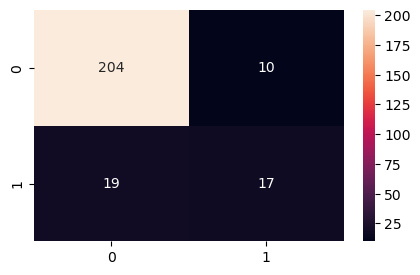

In [182]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, pred)
plt.figure(figsize = (5,3))
sns.heatmap(cm, annot=True, fmt='g')